<a href="https://colab.research.google.com/github/Adryn27/Data-Analytics/blob/main/DIABETES_PREDICTION.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

DIABETES PREDICTION

Dataset diambil dari kaggle: https://www.kaggle.com/datasets/iammustafatz/diabetes-prediction-dataset

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
data = pd.read_csv('Dataset.csv')

In [ ]:
data.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [ ]:
data.tail()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
99995,Female,80.0,0,0,No Info,27.32,6.2,90,0
99996,Female,2.0,0,0,No Info,17.37,6.5,100,0
99997,Male,66.0,0,0,former,27.83,5.7,155,0
99998,Female,24.0,0,0,never,35.42,4.0,100,0
99999,Female,57.0,0,0,current,22.43,6.6,90,0


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB


In [ ]:
data.nunique()

gender                    3
age                     102
hypertension              2
heart_disease             2
smoking_history           6
bmi                    4247
HbA1c_level              18
blood_glucose_level      18
diabetes                  2
dtype: int64

In [ ]:
data.isnull()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...
99995,False,False,False,False,False,False,False,False,False
99996,False,False,False,False,False,False,False,False,False
99997,False,False,False,False,False,False,False,False,False
99998,False,False,False,False,False,False,False,False,False


In [ ]:
data.isnull().sum()

gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64

Setelah melakukan pengecekan, tidak ada data yang bernilai kosong, sehingga tidak perlu melakukan pembersihan data lebih lanjut.

Selanjutnya, dilakukan perubahan nama yang sebelumnya bahasa inggris menjadi bahasa indonesia. Adapun perubahan nilai yang bernilai 0/1 menjadi bertipe string "ya/tidak" agar mudah di interprestasi


In [ ]:
data.rename(columns={"gender":"Jenis_Kelamin",
                     "age":"Usia",
                     "hypertension":"Tekanan_Darah_Tinggi",
                     "heart_disease":"Penyakit_Jantung",
                     "smoking_history":"Riwayat_Merokok",
                     "bmi":"Indeks_Massa_Tubuh",
                     "HbA1c_level":"Kadar_HbA1c",
                     "blood_glucose_level":"Kadar_Gula_Darah",
                     "diabetes":"Diabetes"},inplace=True)
data["Jenis_Kelamin"].replace({"Female":"Wanita",
                               "Male":"Pria",
                               "Other":"Lainnya"},inplace=True)
data["Tekanan_Darah_Tinggi"].replace({0:"Tidak",1:"Ya"},inplace=True)
data["Penyakit_Jantung"].replace({0:"Tidak",1:"Ya"},inplace=True)
data["Diabetes"].replace({0:"Tidak",1:"Ya"},inplace=True)
data["Riwayat_Merokok"].replace({"never":"Tidak Pernah",
                                 "No Info":"Tidak Diketahui",
                                 "former":"Mantan",
                                 "current":"Hingga Saat Ini",
                                 "not current":"Tidak Diketahui Terakhir Kali",
                                 "ever":"Pernah"},inplace=True)
display(data)

,Jenis_Kelamin,Usia,Tekanan_Darah_Tinggi,Penyakit_Jantung,Riwayat_Merokok,Indeks_Massa_Tubuh,Kadar_HbA1c,Kadar_Gula_Darah,Diabetes
0,Wanita,80.0,Tidak,Ya,Tidak Pernah,25.19,6.6,140,Tidak
1,Wanita,54.0,Tidak,Tidak,Tidak Diketahui,27.32,6.6,80,Tidak
2,Pria,28.0,Tidak,Tidak,Tidak Pernah,27.32,5.7,158,Tidak
3,Wanita,36.0,Tidak,Tidak,Hingga Saat Ini,23.45,5.0,155,Tidak
4,Pria,76.0,Ya,Ya,Hingga Saat Ini,20.14,4.8,155,Tidak
...,...,...,...,...,...,...,...,...,...
99995,Wanita,80.0,Tidak,Tidak,Tidak Diketahui,27.32,6.2,90,Tidak
99996,Wanita,2.0,Tidak,Tidak,Tidak Diketahui,17.37,6.5,100,Tidak
99997,Pria,66.0,Tidak,Tidak,Mantan,27.83,5.7,155,Tidak
99998,Wanita,24.0,Tidak,Tidak,Tidak Pernah,35.42,4.0,100,Tidak


In [ ]:
data.describe(include='all')

,Jenis_Kelamin,Usia,Tekanan_Darah_Tinggi,Penyakit_Jantung,Riwayat_Merokok,Indeks_Massa_Tubuh,Kadar_HbA1c,Kadar_Gula_Darah,Diabetes
count,100000,100000.000000,100000,100000,100000,100000.000000,100000.000000,100000.000000,100000
unique,3,NaN,2,2,6,NaN,NaN,NaN,2
top,Wanita,NaN,Tidak,Tidak,Tidak Diketahui,NaN,NaN,NaN,Tidak
freq,58552,NaN,92515,96058,35816,NaN,NaN,NaN,91500
mean,NaN,41.885856,NaN,NaN,NaN,27.320767,5.527507,138.058060,NaN
std,NaN,22.516840,NaN,NaN,NaN,6.636783,1.070672,40.708136,NaN
min,NaN,0.080000,NaN,NaN,NaN,10.010000,3.500000,80.000000,NaN
25%,NaN,24.000000,NaN,NaN,NaN,23.630000,4.800000,100.000000,NaN
50%,NaN,43.000000,NaN,NaN,NaN,27.320000,5.800000,140.000000,NaN
75%,NaN,60.000000,NaN,NaN,NaN,29.580000,6.200000,159.000000,NaN


Dari hasil describe tersebut, diketahui bahwa ringkasan statistik dari dataset yang dianalisis, yaitu.
1. Jenis kelamin “Wanita” menjadikan responden dengan jumlah yang paling
banyak dengan jumlah berkisar 58,552% responden dari 100% responden
yang ada pada penelitian ini.
2. Usia rata-rata responden berkisar 41 tahun dengan rentang usia 8 bulan
hingga 80 tahun.
3. Jumlah responden pada penelitian ini didominasi oleh responden yang tidak memiliki tekanan darah tinggi dengan jumlah berkisar 92,515%.
4. Jumlah responden yang tidak memiliki penyakit jantung mendominasi pada
penelitian ini dengan jumlah berkisar 96,058%.
5. Peneliti masih tidak mengetahui 35,816% responden terhadap Riwayat
merokok mereka. Indeks Massa Tubuh rata-rata responden berkisar 27,32
dengan rentang 10,01 hingga 95,69.
6. Kadar HbA1c rata-rata responden berkisar 5,5% dengan rentang 3,5% hingga
9,0%.
7. Kadar gula darah rata-rata responden berkisar 138 mg/dL dengan rentang 80 hingga 300 mg/dL.
8. Berdasarkan beberapa faktor tersebut, peneliti mengungkapkan bahwa
responden yang mengikuti penelitian ini 91,5% tidak mengidap penyakit
diabetes.

In [ ]:
data.dtypes

Jenis_Kelamin            object
Usia                    float64
Tekanan_Darah_Tinggi     object
Penyakit_Jantung         object
Riwayat_Merokok          object
Indeks_Massa_Tubuh      float64
Kadar_HbA1c             float64
Kadar_Gula_Darah          int64
Diabetes                 object
dtype: object

Untuk melakukan visualisasi data, perlu diketahui terlebih dahulu mana yang termasuk categorical variable dan mana yang termasuk numerical variable untuk mempermudah proses visualisasi data

In [ ]:
dataobject=data.select_dtypes(include=['object']).columns
datanumeric=data.select_dtypes(include=np.number).columns.tolist()
print("Categorical Variables:")
print(dataobject)
print("Numerical Variables:")
print(datanumeric)

Categorical Variables:
Index(['Jenis_Kelamin', 'Tekanan_Darah_Tinggi', 'Penyakit_Jantung',
       'Riwayat_Merokok', 'Diabetes'],
      dtype='object')
Numerical Variables:
['Usia', 'Indeks_Massa_Tubuh', 'Kadar_HbA1c', 'Kadar_Gula_Darah']


Usia
skew : -0.05


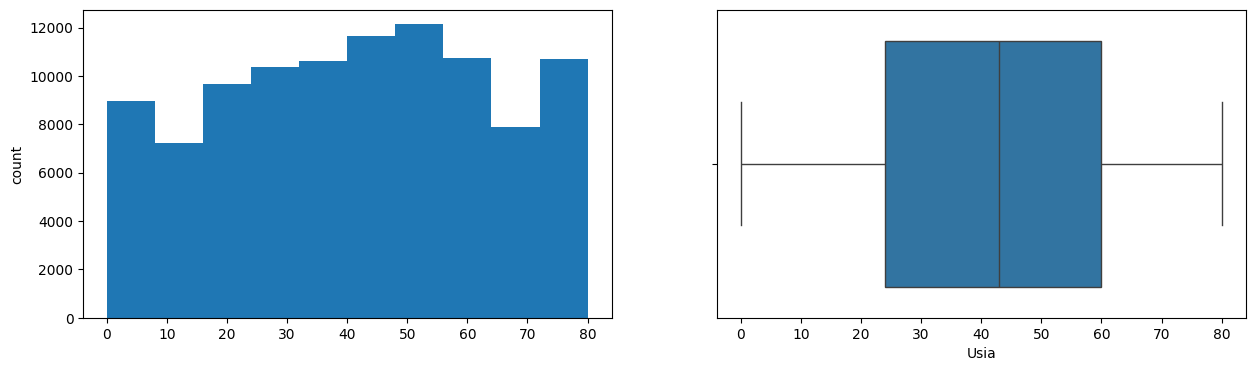

Indeks_Massa_Tubuh
skew : 1.04


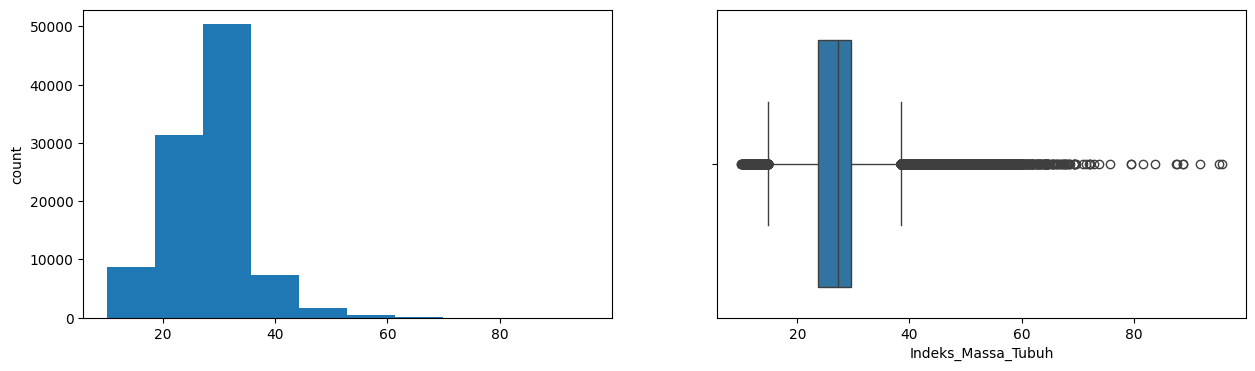

Kadar_HbA1c
skew : -0.07


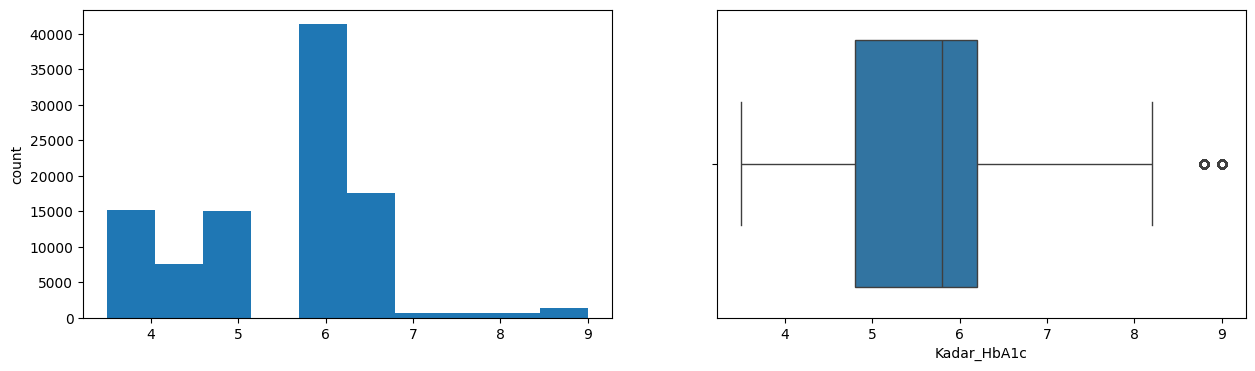

Kadar_Gula_Darah
skew : 0.82


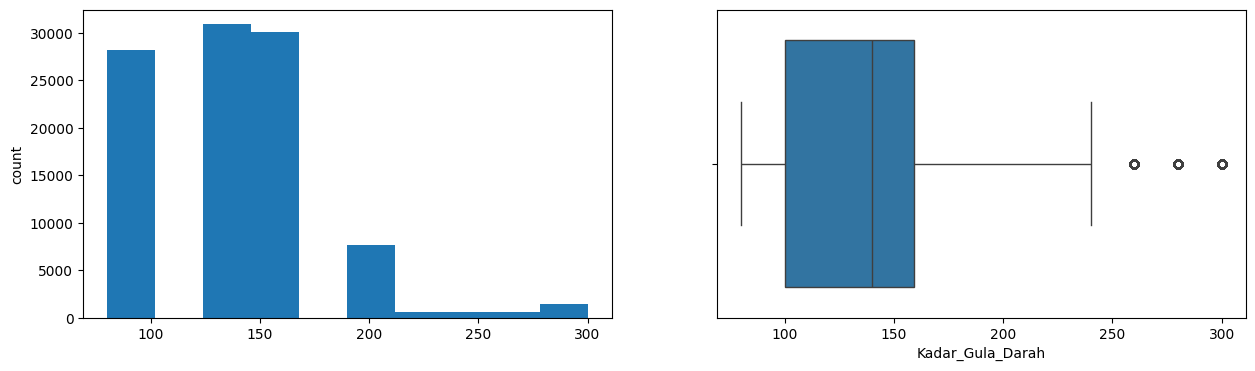

In [ ]:
for col in datanumeric:
    print(col)
    print('skew :', round(data[col].skew(),2))
    plt.figure(figsize=(15,4))
    plt.subplot(1,2,1)
    data[col].hist(grid=False)
    plt.ylabel('count')
    plt.subplot(1,2,2)
    sns.boxplot(x=data[col])
    plt.show()

Dari hasil visualisasi data berupa histogram dan boxplot, diketahui bahwa.
1. Usia
* Sumbu X (horizontal) mewakili rentang usia, yang berkisar dari 0 hingga
tahun dan Sumbu Y (vertikal) mewakili jumlah (count) individu dalam
masing-masing interval usia.
* Rentang usia responden mulai dari usia 8 bulan hingga 80 tahun.
* Puncak tertinggi usia responden berusia 50 tahun hingga 58 tahun.
2. Indeks Massa Tubuh
* Sumbu X (horizontal) mewakili rentang nilai Indeks Massa Tubuh (BMI) dan
Sumbu Y (vertikal) mewakili jumlah (count) individu dalam masing-masing
interval BMI
* Rentang indeks massa tubuh berkisar 10 hingga 70.
* Puncak tertinggi responden terhadap indeks massa tubuh berkisar 30 hingga
37 dan terendah berkisar 62 hingga 70.
3. Kadar HbA1c
* Sumbu X (horizontal) mewakili rentang kadar HbA1c dan Sumbu Y
(vertikal) mewakili jumlah (count) individu dalam masing-masing interval
kadar HbA1c.
* Rentang kadar HbA1c berkisar mulai dari 3,5% hingga 9%.
* Puncak tertinggi responden terhadap kadar HbA1c berkisar 5,8% hingga
6,2% dan terendah berkisar 6,8% hingga 8,5%.
4. Kadar Gula Darah
* Sumbu X (horizontal) mewakili rentang Kadar_Gula_darah.
* Sumbu Y (vertikal) mewakili jumlah (count) individu dalam masing-masing
interval Kadar_Gula_darah
* Rentang kadar gula darah berkisar 80 mg/dL hingga 300 mg/dL.
* Puncak tertinggi responden terhadap kadar gula darah berkisar 125 mg/dL
hingga 145 mg/dL dan terendah berkisar 210 mg/dL hingga 275 mg/dL.

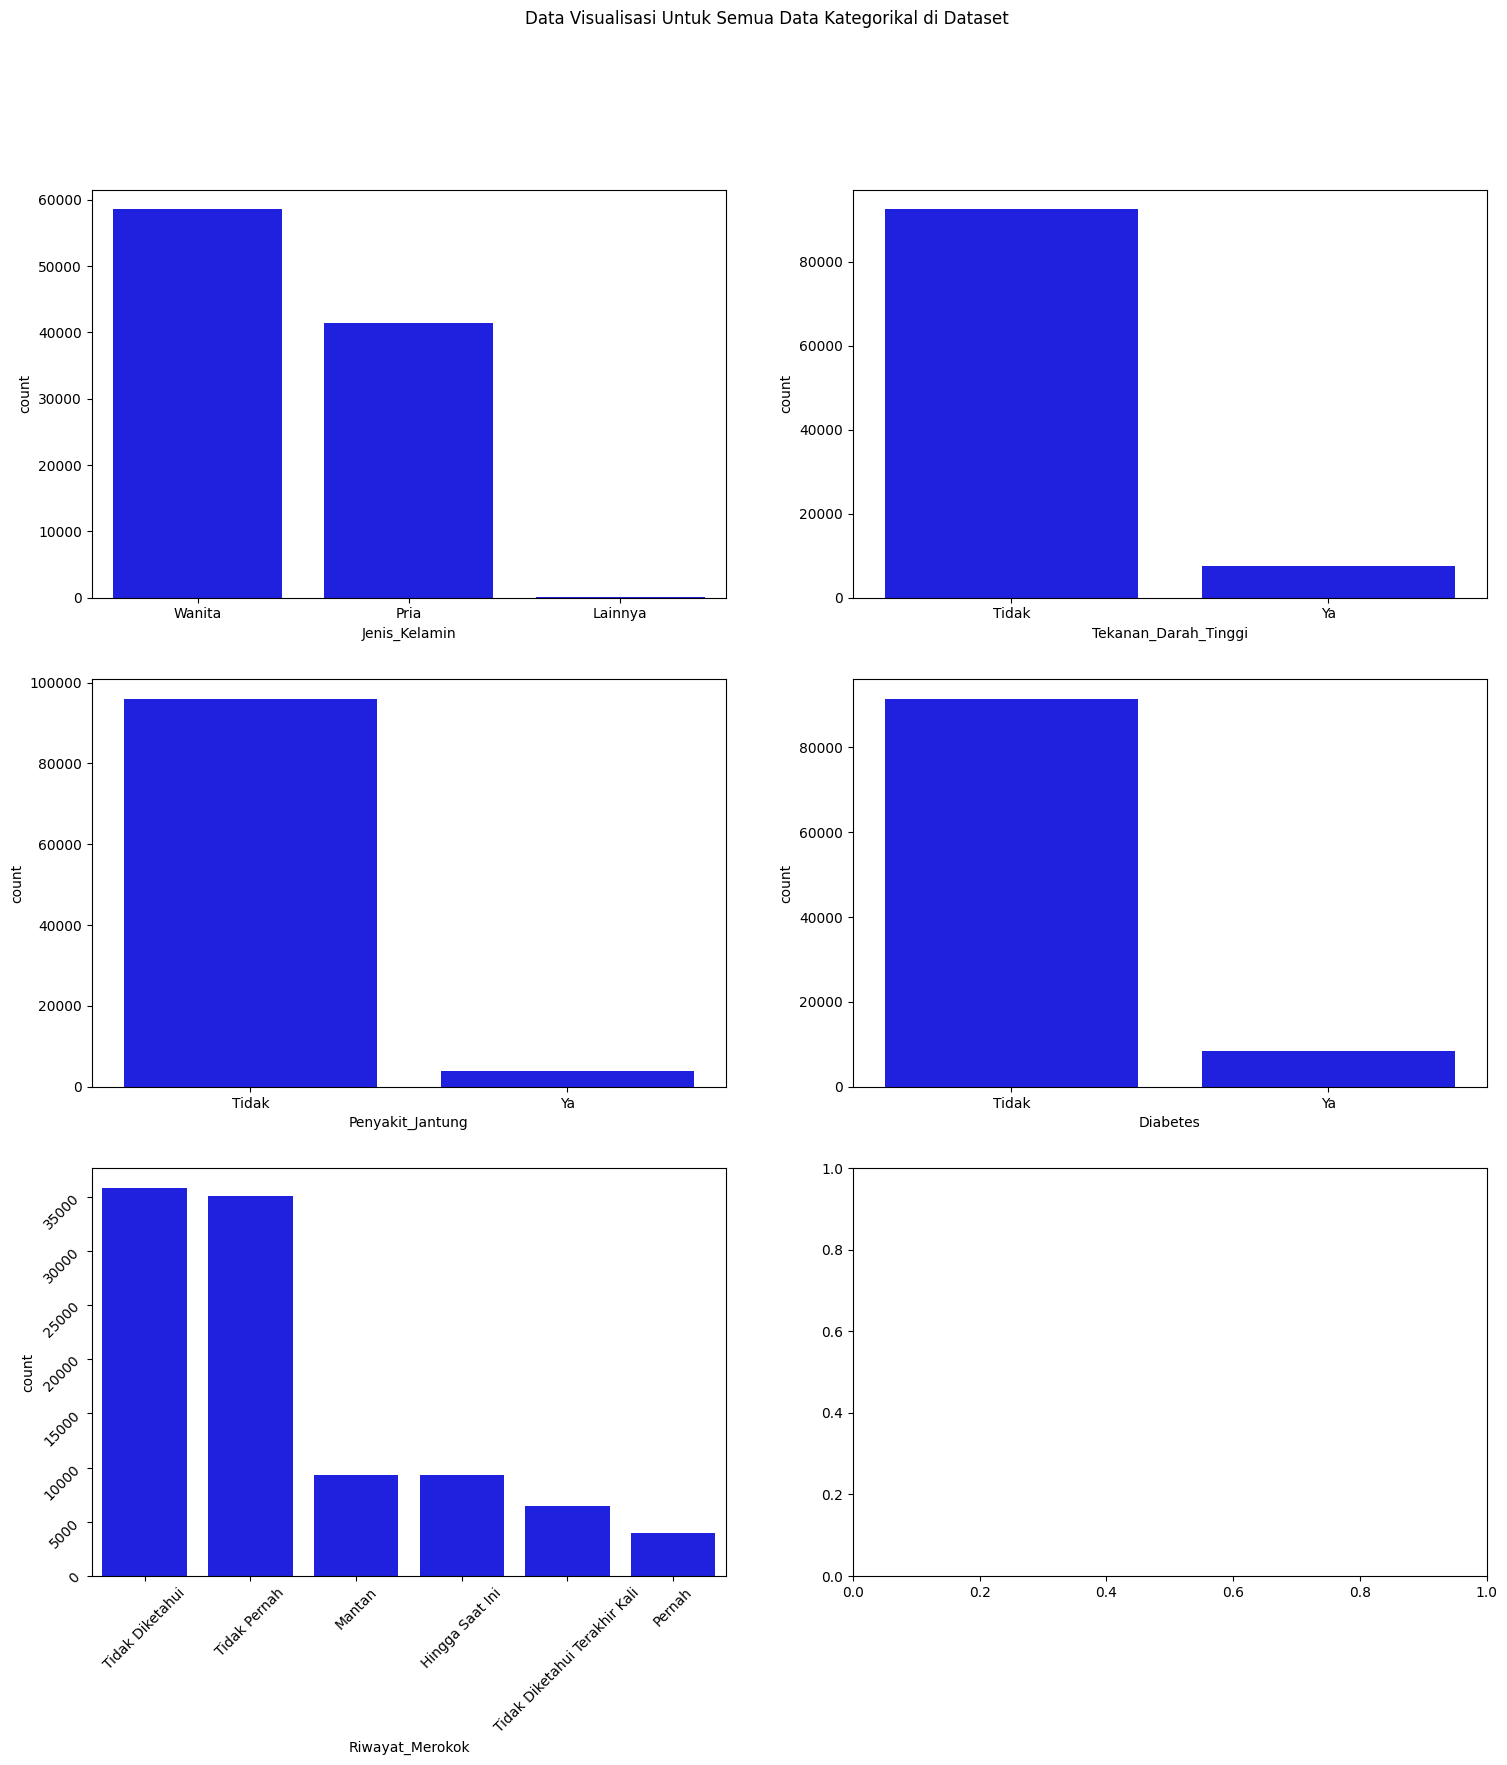

In [ ]:
fig, axes=plt.subplots(3, 2, figsize=(18, 18))
fig.suptitle('Data Visualisasi Untuk Semua Data Kategorikal di Dataset')
sns.countplot(ax=axes[0,0], x='Jenis_Kelamin', data=data, color='blue',
              order=data['Jenis_Kelamin'].value_counts().index);
sns.countplot(ax=axes[0,1], x='Tekanan_Darah_Tinggi', data=data, color='blue',
              order=data['Tekanan_Darah_Tinggi'].value_counts().index);
sns.countplot(ax=axes[1,0], x='Penyakit_Jantung', data=data, color='blue',
              order=data['Penyakit_Jantung'].value_counts().index);
sns.countplot(ax=axes[2,0], x='Riwayat_Merokok', data=data, color='blue',
              order=data['Riwayat_Merokok'].value_counts().index);
sns.countplot(ax=axes[1,1], x='Diabetes', data=data, color='blue',
              order=data['Diabetes'].value_counts().index);
axes[2][0].tick_params(labelrotation=45);

Dari hasil visualisasi countplot diatas, ditemukan bahwa.
* Jenis kelamin Wanita menjadi jumlah responden terbanyak hingga 58,522%,
diikuti dengan jenis kelamin pria, dan lainnya sebagai jumlah responden
terendah.
* Jumlah responden yang tidak memiliki tekanan darah tinggi lebih banyak
berkisar 92,515% dari 100% jumlah responden.
* Jumlah responden yang tidak memiliki penyakit jantung mendominasi
dengan jumlah berkisar 96.058% dari 100% jumlah responden.
* Dari keseluruhan jumlah responden yang mengikuti penelitian ini, sebagian
besar tidak terkena diabetes yakni berkisar 91,5%, yang berarti hanya
berkisar 8,5% yang terkena diabetes dan ini merupakan hal yang baik di
dunia medis.
* Dari analisis diatas jumlah responden yang masih tidak diketahui Riwayat merokoknya merupakan yang terbanyak. Hal ini menunjukkan peneliti masih
banyak belum mengetahui Riwayat merokok responden. Selanjutnya jumlah
terbanyak diikuti dengan tidak pernah dan pernah sebagai jumlah paling
sedikit, hal ini dapat kita ketahui bahwa responden masih banyak memikirkan
kesehatan mereka.

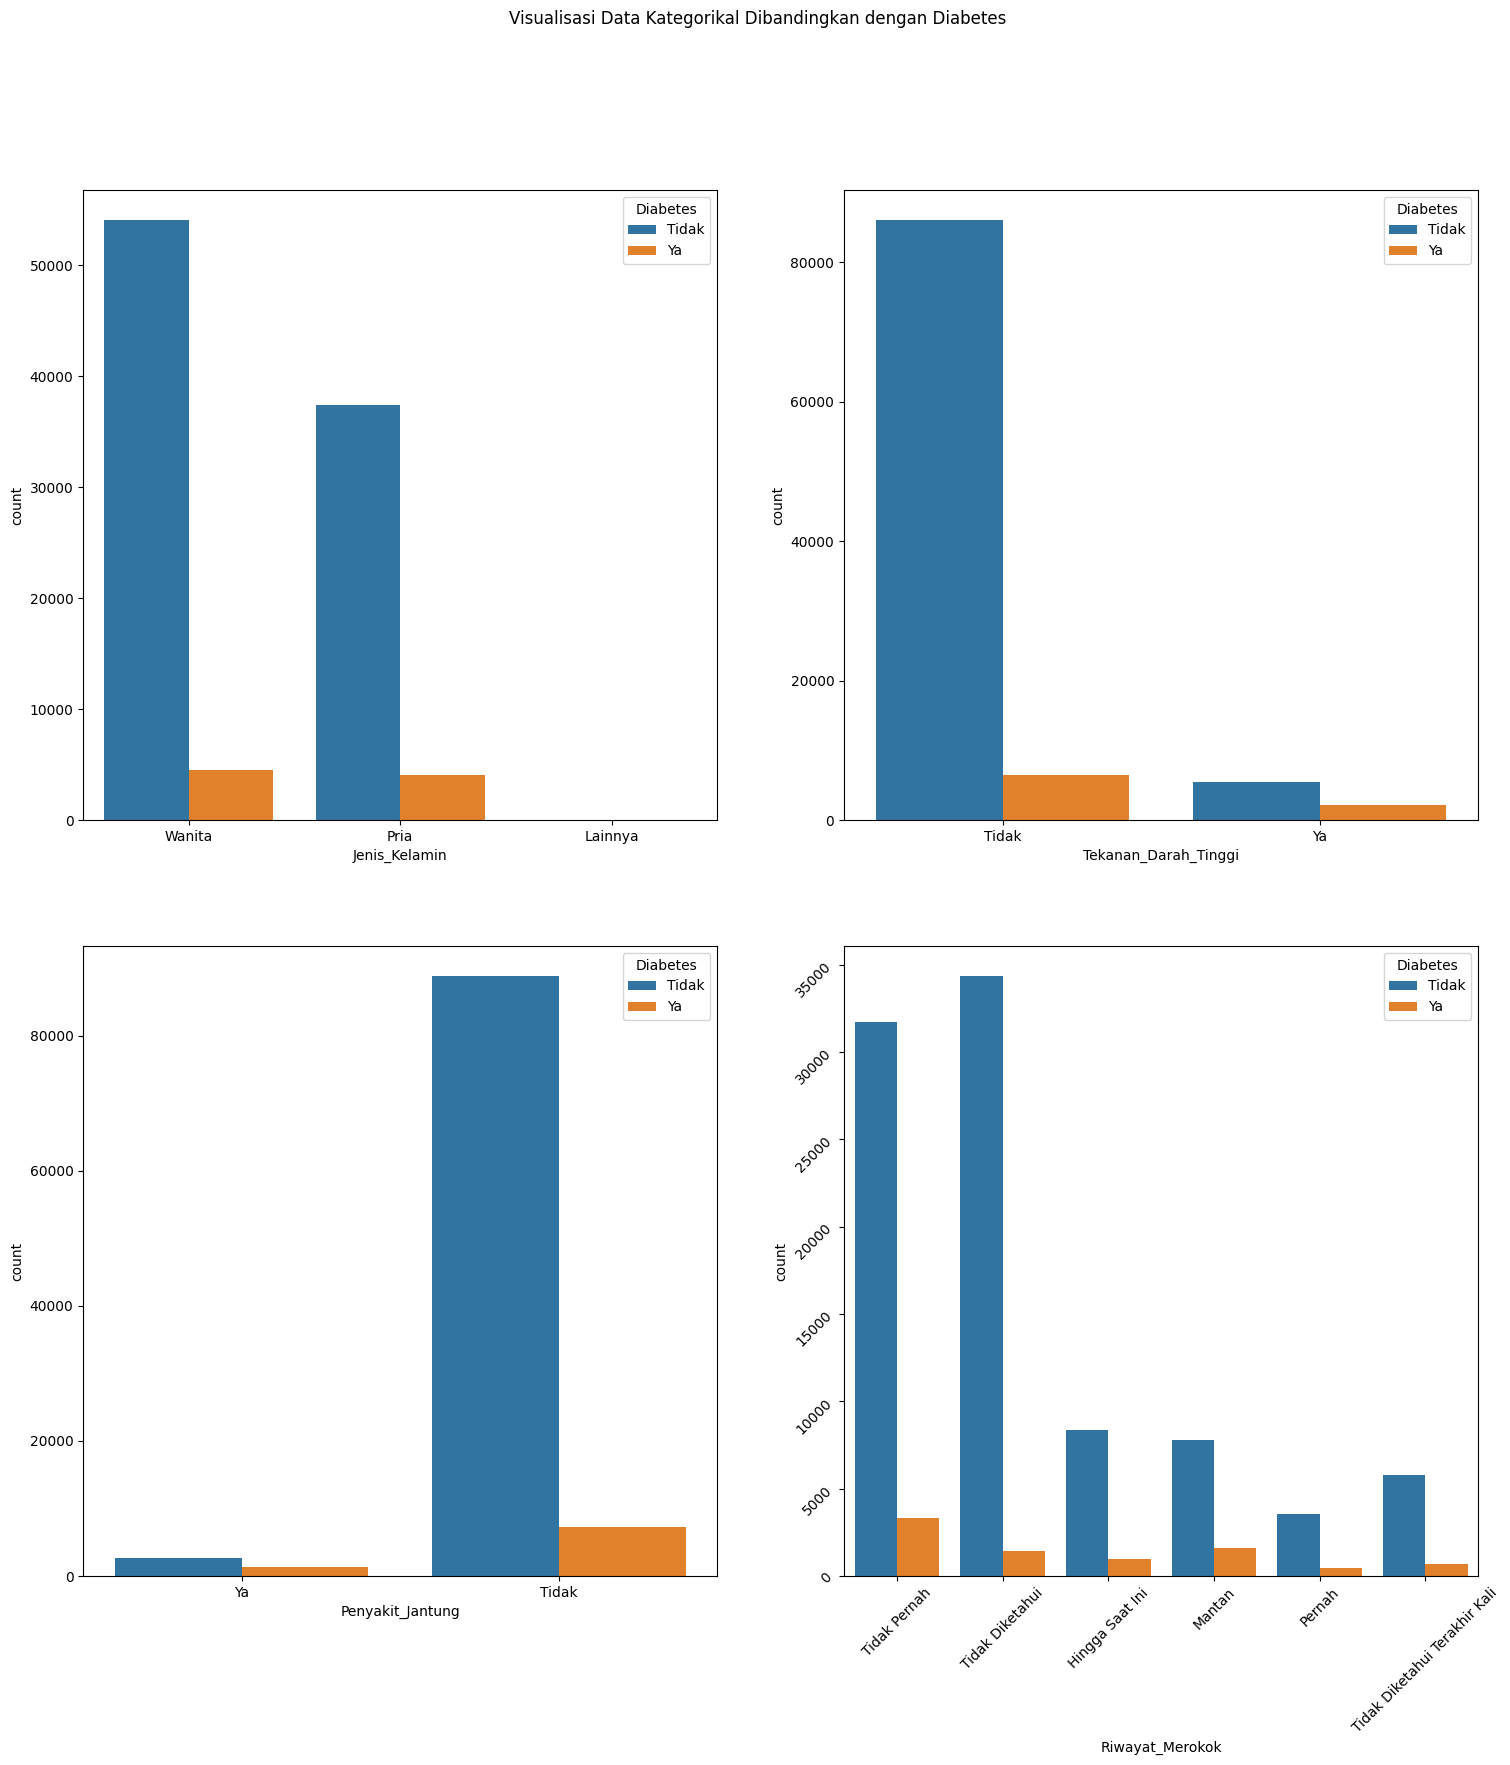

In [ ]:
fig, axes=plt.subplots(2, 2, figsize=(18, 18))
fig.suptitle('Visualisasi Data Kategorikal Dibandingkan dengan Diabetes')
sns.countplot(ax=axes[0,0], x='Jenis_Kelamin', hue='Diabetes', data=data)
sns.countplot(ax=axes[0,1], x='Tekanan_Darah_Tinggi', hue='Diabetes', data=data)
sns.countplot(ax=axes[1,0], x='Penyakit_Jantung', hue='Diabetes', data=data)
sns.countplot(ax=axes[1,1], x='Riwayat_Merokok', hue='Diabetes', data=data)
axes[1][1].tick_params(labelrotation=45);

Dari hasil visualisasi data countplot diatas yang membandingkan data dengan variable kategorikal dengan diabetes, ditemukan bahwa.
* Dari visualisasi data diatas dapat dilihat ketimpangan yang cukup jauh antara yang tidak terkena diabetes dan yang terkena diabetes, baik berdasarkan jenis
kelamin maupun tekanan darah tinggi.
* Dari visualisasi data diatas juga kita dapat analisis bahwa dari sekian banyak responden baik berdasarkan jenis kelamin maupun tekanan darah tinggi
hanya sebagian kecil saja responden yang terkena diabetes, bahkan tidak
sampai setengah dari jumlah responden berdasarkan jenis kelamin maupun
tekanan darah tinggi.
* Walaupun jika dilihat dari visualisasi data diatas hanya sebagian kecil yang terkena diabetes. Akan tetapi, perlu dilihat jumlah perbandingan antara “ya” dan “tidak” pada masing-masing nilai. Bisa dilihat pada bagian jenis kelamin menunjukkan yang paling banyak terkena penyakit diabetes adalah pria, dikarenakan jumlah responden pria jumlahnya lebih sedikit dari jumlah responden wanita, akan tetapi jumlah responden yang terkena diabetes/”ya” hampir setara dengan responden wanita yang terkena diabetes. Begitupun dengan tekanan darah tinggi, yang paling banyak terkena penyakit diabetes adalah yang memiliki tekanan darah tinggi/”ya” yang jumlahnya hampir setengah dari jumlah responden yang tidak terkena diabetes.
* Dari visualisasi data diatas dapat dilihat ketimpangan yang cukup jauh antara
yang tidak terkena diabetes dan yang terkena diabetes, baik berdasarkan
Penyakit jantung dan Riwayat merokok.
* Dari visualisasi data diatas kita dapat menganalisis bahwa jumlah yang
terkena diabetes hanya sebagian kecil saja dan bahkan tidak sampai setengah
dari jumlah responden yang ada berdasarkan penyakit jantung dan Riwayat
merokok.
* Bisa dilihat pada bagian penyakit jantung menunjukkan yang paling banyak
terkena penyakit diabetes adalah kategori “ya”/yang memiliki penyakit
jantung, dikarenakan perbandingan pada kategori “ya”/yang memiliki
penyakit jantung jumlah respondennya sedikit dan jumlah yang terkena
diabetes/orange hampir setengah dari yang tidak terkena diabetes/biru.
Begitupun dengan riwayat merokok, yang paling banyak terkena penyakit
diabetes adalah yang pernah, mantan, hingga saat ini, dan pernah tapi tidak
diketahui terakhir kali merokok dibandingkan dengan yang tidak pernah maupun tidak diketahui

<Axes: xlabel='Kadar_Gula_Darah', ylabel='Density'>

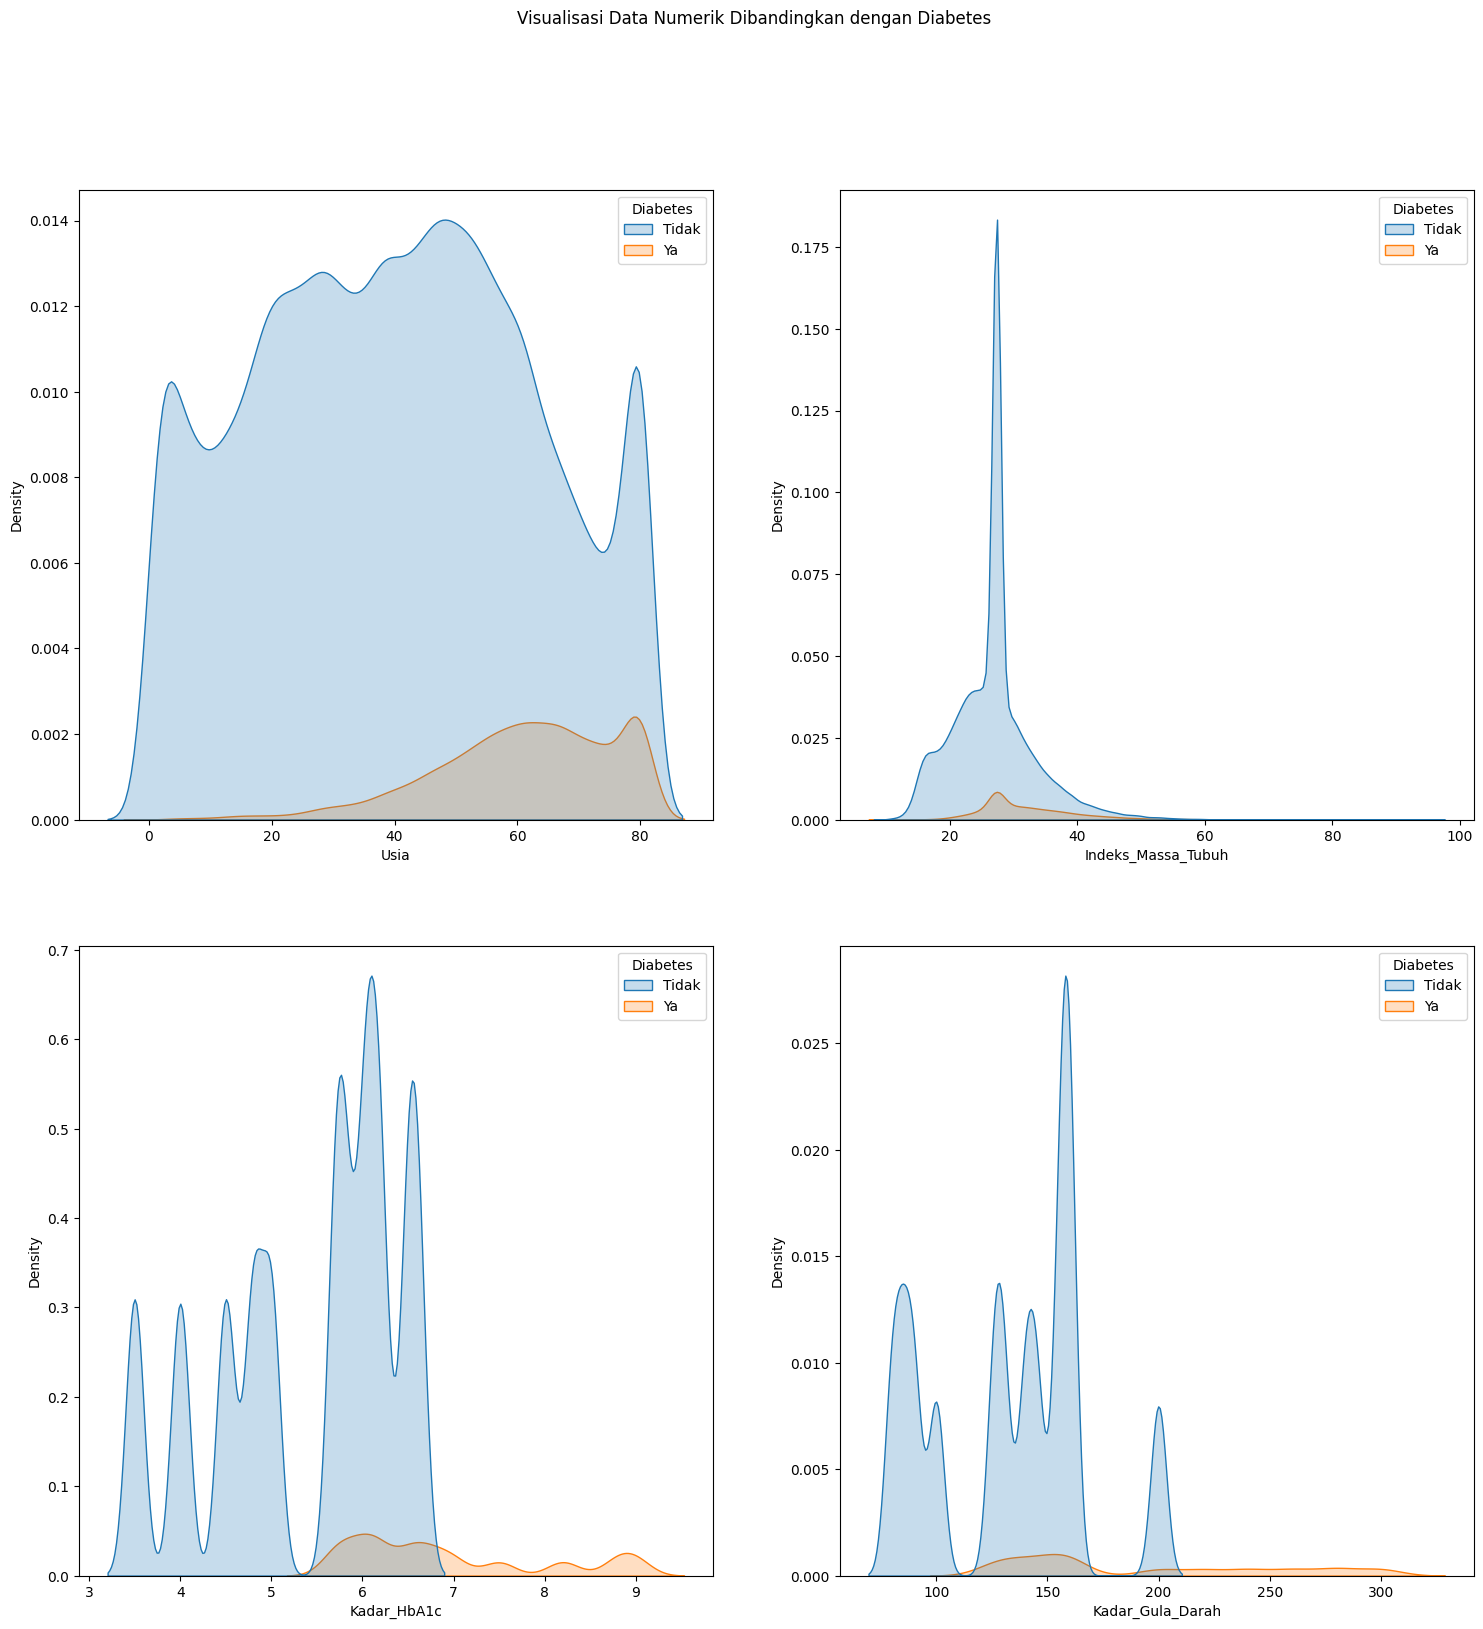

In [ ]:
fig, axes=plt.subplots(2, 2, figsize=(18, 18))
fig.suptitle('Visualisasi Data Numerik Dibandingkan dengan Diabetes')
sns.kdeplot(ax=axes[0,0], x='Usia', hue='Diabetes', data=data, fill=True)
sns.kdeplot(ax=axes[0,1], x='Indeks_Massa_Tubuh', hue='Diabetes', data=data, fill=True)
sns.kdeplot(ax=axes[1,0], x='Kadar_HbA1c', hue='Diabetes', data=data, fill=True)
sns.kdeplot(ax=axes[1,1], x='Kadar_Gula_Darah', hue='Diabetes', data=data, fill=True)

Dari hasil visualisasi data dengan menggunakan density plot untuk membandingkan data numerik dengan diabetes, ditemukan bahwa.
* Dari hasil visualisasi data diatas dapat dilihat perbedaan yang sangat jauh antara yang terkena diabetes maupun yang tidak.
* Berdasarkan usia, rentang yang terkena diabetes berkisar usia 1 tahun hingga 80 tahun dengan Tingkat kepadatan mulai dari usia 20 tahun hingga 80 tahun dengan puncak tertinggi pada usia 80 tahun.
* Berdasarkan indeks massa tubuh , rentang yang terkena diabetes dan
kepadatannya berkisar 20 kg/m2 hingga 50 kg/m2 dengan puncak tertinggi
berkisar 25 kg/m2.
* Dari hasil visualisasi diatas menunjukkan ketimpangan yang sangat jauh
antara yang terkena diabetes dan tidak.
* Berdasarkan kadar HbA1c, rentang dan kepadatan yang terkena diabetes
mulai dari 5,4% hingga 9% dengan puncak tertinggi pada kadar HbA1c
berkisar 6%.
* Berdasarkan kadar gula darah, rentang dan kepadatan yang terkena diabetes
mulai dari 100 mg/dL hingga 300 mg/dL dengan puncah tertinggi pada 150
mg/dL.